In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

# Load BLS employment data
bls = pd.read_excel(
    "../data/oews_2025/oesm25nat/national_M2025_dl.xlsx",
    dtype={"OCC_CODE": str}
)

print("BLS shape:", bls.shape)
print("\nColumns:", bls.columns.tolist())
print("\nFirst few rows:")
bls.head(3)

BLS shape: (1401, 32)

Columns: ['AREA', 'AREA_TITLE', 'AREA_TYPE', 'PRIM_STATE', 'NAICS', 'NAICS_TITLE', 'I_GROUP', 'OWN_CODE', 'OCC_CODE', 'OCC_TITLE', 'O_GROUP', 'TOT_EMP', 'EMP_PRSE', 'JOBS_1000', 'LOC_QUOTIENT', 'PCT_TOTAL', 'PCT_RPT', 'H_MEAN', 'A_MEAN', 'MEAN_PRSE', 'H_PCT10', 'H_PCT25', 'H_MEDIAN', 'H_PCT75', 'H_PCT90', 'A_PCT10', 'A_PCT25', 'A_MEDIAN', 'A_PCT75', 'A_PCT90', 'ANNUAL', 'HOURLY']

First few rows:


,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,H_MEDIAN,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY
0,99,U.S.,1,US,0,Cross-industry,cross-industry,1235,00-0000,All Occupations,...,24.51,38.71,61.81,31200,37590,50980,80520,128560,NaN,NaN
1,99,U.S.,1,US,0,Cross-industry,cross-industry,1235,11-0000,Management Occupations,...,60.83,84.75,123.71,60130,82970,126520,176280,257310,NaN,NaN
2,99,U.S.,1,US,0,Cross-industry,cross-industry,1235,11-1000,Top Executives,...,52.17,82.85,134.48,50480,73260,108510,172330,279710,NaN,NaN


In [2]:
# Load Felten AIOE data
aioe = pd.read_excel(
    "../data/AIOE_DataAppendix.xlsx",
    sheet_name=None  # Load all sheets to see what's inside
)

print("Sheets available:", list(aioe.keys()))

Sheets available: ['Index', 'Appendix A', 'Appendix B', 'Appendix C', 'Appendix D', 'Appendix E']


In [3]:
# Load Appendix A - AIOE scores by occupation
aioe_occ = pd.read_excel(
    "../data/AIOE_DataAppendix.xlsx",
    sheet_name="Appendix A"
)

print("Shape:", aioe_occ.shape)
print("\nColumns:", aioe_occ.columns.tolist())
print("\nFirst few rows:")
aioe_occ.head()

Shape: (774, 3)

Columns: ['SOC Code', 'Occupation Title', 'AIOE']

First few rows:


,SOC Code,Occupation Title,AIOE
0,11-1011,Chief Executives,1.334246
1,11-1021,General and Operations Managers,0.574877
2,11-2011,Advertising and Promotions Managers,1.294387
3,11-2021,Marketing Managers,1.315032
4,11-2022,Sales Managers,1.266280


In [4]:
# Clean BLS data - keep only detailed occupations, national level
bls_clean = bls[
    (bls["O_GROUP"] == "detailed") &
    (bls["I_GROUP"] == "cross-industry")
].copy()

# Clean up key columns
bls_clean = bls_clean[["OCC_CODE", "OCC_TITLE", "TOT_EMP", "A_MEDIAN"]].copy()
bls_clean.columns = ["SOC Code", "occupation", "total_emp", "annual_wage"]

# Convert to numeric (BLS uses * and # for suppressed values)
bls_clean["total_emp"] = pd.to_numeric(bls_clean["total_emp"], errors="coerce")
bls_clean["annual_wage"] = pd.to_numeric(bls_clean["annual_wage"], errors="coerce")

# Clean AIOE SOC codes to match BLS format
aioe_occ["SOC Code"] = aioe_occ["SOC Code"].astype(str).str.strip()

# Merge on SOC Code
merged = bls_clean.merge(aioe_occ[["SOC Code", "AIOE"]], on="SOC Code", how="inner")

print("Merged shape:", merged.shape)
print("\nSample:")
merged.head()

Merged shape: (673, 5)

Sample:


,SOC Code,occupation,total_emp,annual_wage,AIOE
0,11-1011,Chief Executives,204350,213990.0,1.334246
1,11-1021,General and Operations Managers,3503020,105770.0,0.574877
2,11-2011,Advertising and Promotions Managers,21470,133660.0,1.294387
3,11-2021,Marketing Managers,395240,166790.0,1.315032
4,11-2022,Sales Managers,637080,148270.0,1.266280


In [5]:
# Drop missing values
df = merged.dropna(subset=["total_emp", "annual_wage", "AIOE"]).copy()

# Categorize AI exposure into quartiles
df["ai_exposure_level"] = pd.qcut(
    df["AIOE"], 
    q=4, 
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

print("Occupations per exposure level:")
print(df["ai_exposure_level"].value_counts().sort_index())
print(f"\nTotal occupations: {len(df)}")
print(f"Total employment covered: {df['total_emp'].sum():,.0f}")

Occupations per exposure level:
ai_exposure_level
Low            168
Medium-Low     167
Medium-High    167
High           168
Name: count, dtype: int64

Total occupations: 670
Total employment covered: 122,921,830


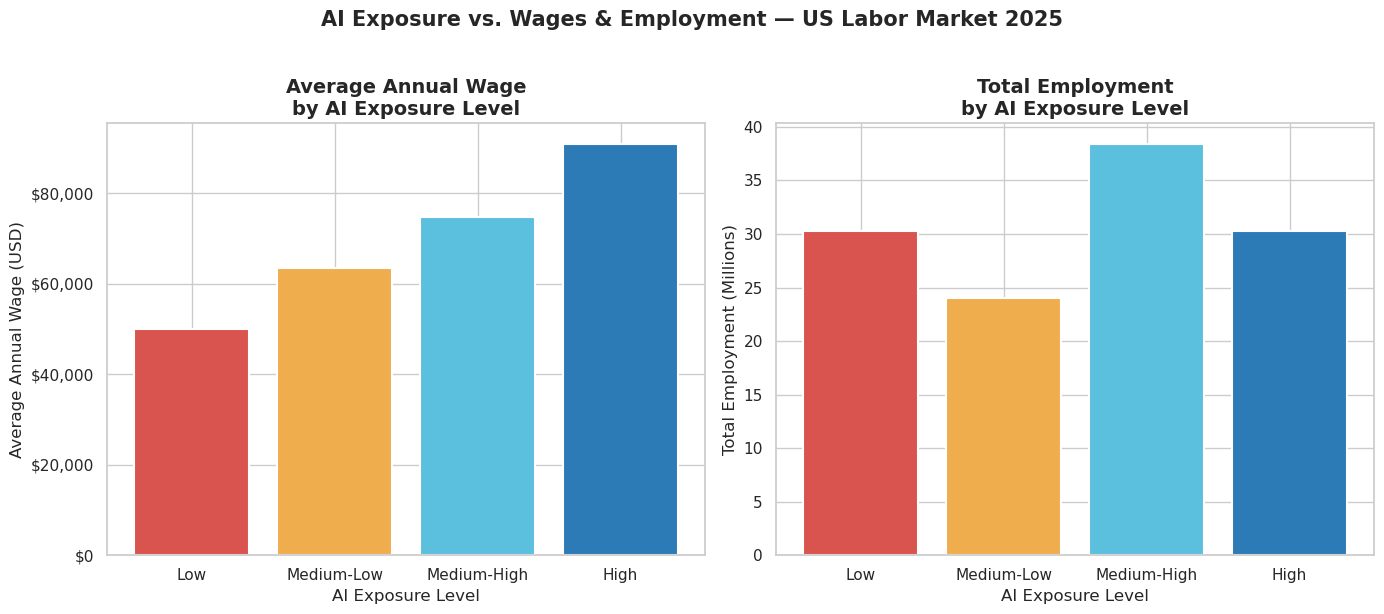

In [6]:
# Average wage by AI exposure level
wage_by_exposure = df.groupby("ai_exposure_level", observed=True).agg(
    avg_wage=("annual_wage", "mean"),
    total_emp=("total_emp", "sum"),
    count=("occupation", "count")
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Average wage by AI exposure
colors = ["#d9534f", "#f0ad4e", "#5bc0de", "#2c7bb6"]
axes[0].bar(
    wage_by_exposure["ai_exposure_level"],
    wage_by_exposure["avg_wage"],
    color=colors, edgecolor="white", linewidth=1.5
)
axes[0].set_title("Average Annual Wage\nby AI Exposure Level", 
                   fontsize=14, fontweight="bold")
axes[0].set_xlabel("AI Exposure Level")
axes[0].set_ylabel("Average Annual Wage (USD)")
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}")
)

# Chart 2: Employment share by AI exposure
axes[1].bar(
    wage_by_exposure["ai_exposure_level"],
    wage_by_exposure["total_emp"] / 1e6,
    color=colors, edgecolor="white", linewidth=1.5
)
axes[1].set_title("Total Employment\nby AI Exposure Level", 
                   fontsize=14, fontweight="bold")
axes[1].set_xlabel("AI Exposure Level")
axes[1].set_ylabel("Total Employment (Millions)")

plt.suptitle("AI Exposure vs. Wages & Employment — US Labor Market 2025",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/ai_exposure_wage_employment.png", 
            dpi=150, bbox_inches="tight")
plt.show()

In [7]:
import statsmodels.api as sm

# OLS regression: log wage ~ AI exposure
df["log_wage"] = np.log(df["annual_wage"])
df["log_emp"] = np.log(df["total_emp"])

# Regression 1: AI exposure → wages
X1 = sm.add_constant(df["AIOE"])
model1 = sm.OLS(df["log_wage"], X1).fit()

# Regression 2: AI exposure → employment
X2 = sm.add_constant(df["AIOE"])
model2 = sm.OLS(df["log_emp"], X2).fit()

print("=" * 50)
print("REGRESSION 1: Log Wage ~ AI Exposure")
print("=" * 50)
print(f"Coefficient: {model1.params['AIOE']:.4f}")
print(f"p-value:     {model1.pvalues['AIOE']:.4f}")
print(f"R-squared:   {model1.rsquared:.4f}")

print("\n" + "=" * 50)
print("REGRESSION 2: Log Employment ~ AI Exposure")
print("=" * 50)
print(f"Coefficient: {model2.params['AIOE']:.4f}")
print(f"p-value:     {model2.pvalues['AIOE']:.4f}")
print(f"R-squared:   {model2.rsquared:.4f}")

REGRESSION 1: Log Wage ~ AI Exposure
Coefficient: 0.2122
p-value:     0.0000
R-squared:   0.2758

REGRESSION 2: Log Employment ~ AI Exposure
Coefficient: 0.1436
p-value:     0.0277
R-squared:   0.0072


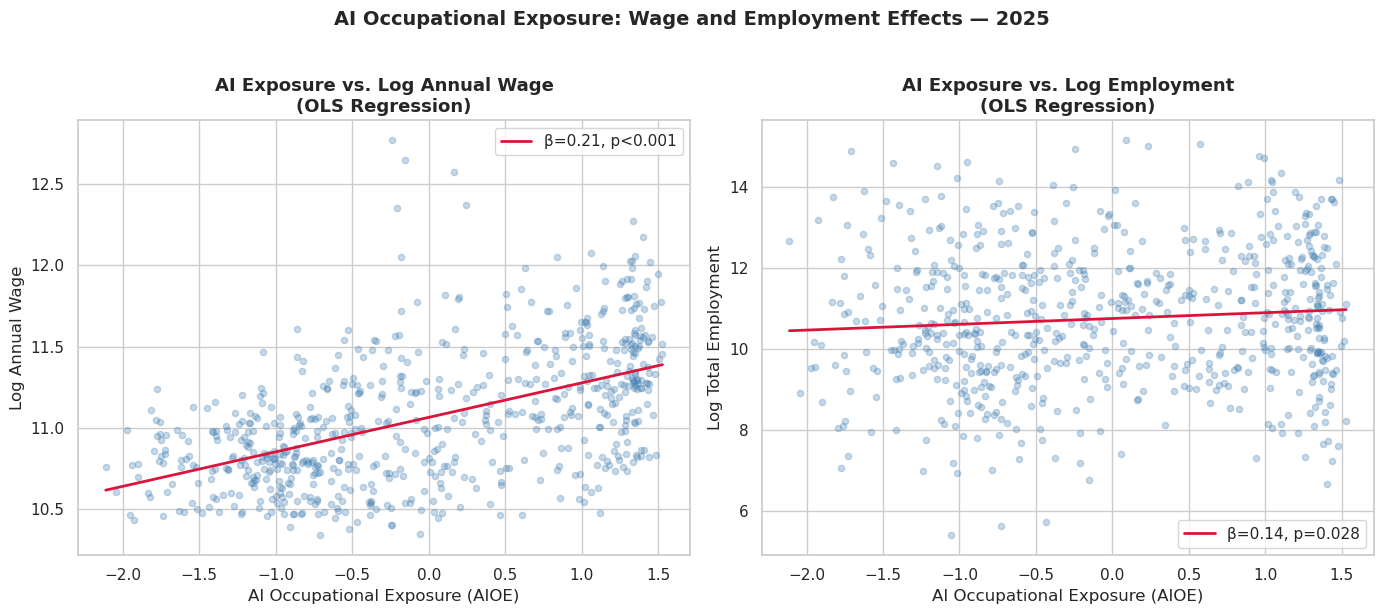

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: AIOE vs Log Wage
axes[0].scatter(df["AIOE"], df["log_wage"], 
                alpha=0.3, s=20, color="steelblue")
# Regression line
x_range = np.linspace(df["AIOE"].min(), df["AIOE"].max(), 100)
axes[0].plot(x_range, 
             model1.params["const"] + model1.params["AIOE"] * x_range,
             color="crimson", linewidth=2, label=f"β=0.21, p<0.001")
axes[0].set_title("AI Exposure vs. Log Annual Wage\n(OLS Regression)", 
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("AI Occupational Exposure (AIOE)")
axes[0].set_ylabel("Log Annual Wage")
axes[0].legend()

# Plot 2: AIOE vs Log Employment
axes[1].scatter(df["AIOE"], df["log_emp"], 
                alpha=0.3, s=20, color="steelblue")
axes[1].plot(x_range,
             model2.params["const"] + model2.params["AIOE"] * x_range,
             color="crimson", linewidth=2, label=f"β=0.14, p=0.028")
axes[1].set_title("AI Exposure vs. Log Employment\n(OLS Regression)", 
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel("AI Occupational Exposure (AIOE)")
axes[1].set_ylabel("Log Total Employment")
axes[1].legend()

plt.suptitle("AI Occupational Exposure: Wage and Employment Effects — 2025",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/ai_regression.png", dpi=150, bbox_inches="tight")
plt.show()

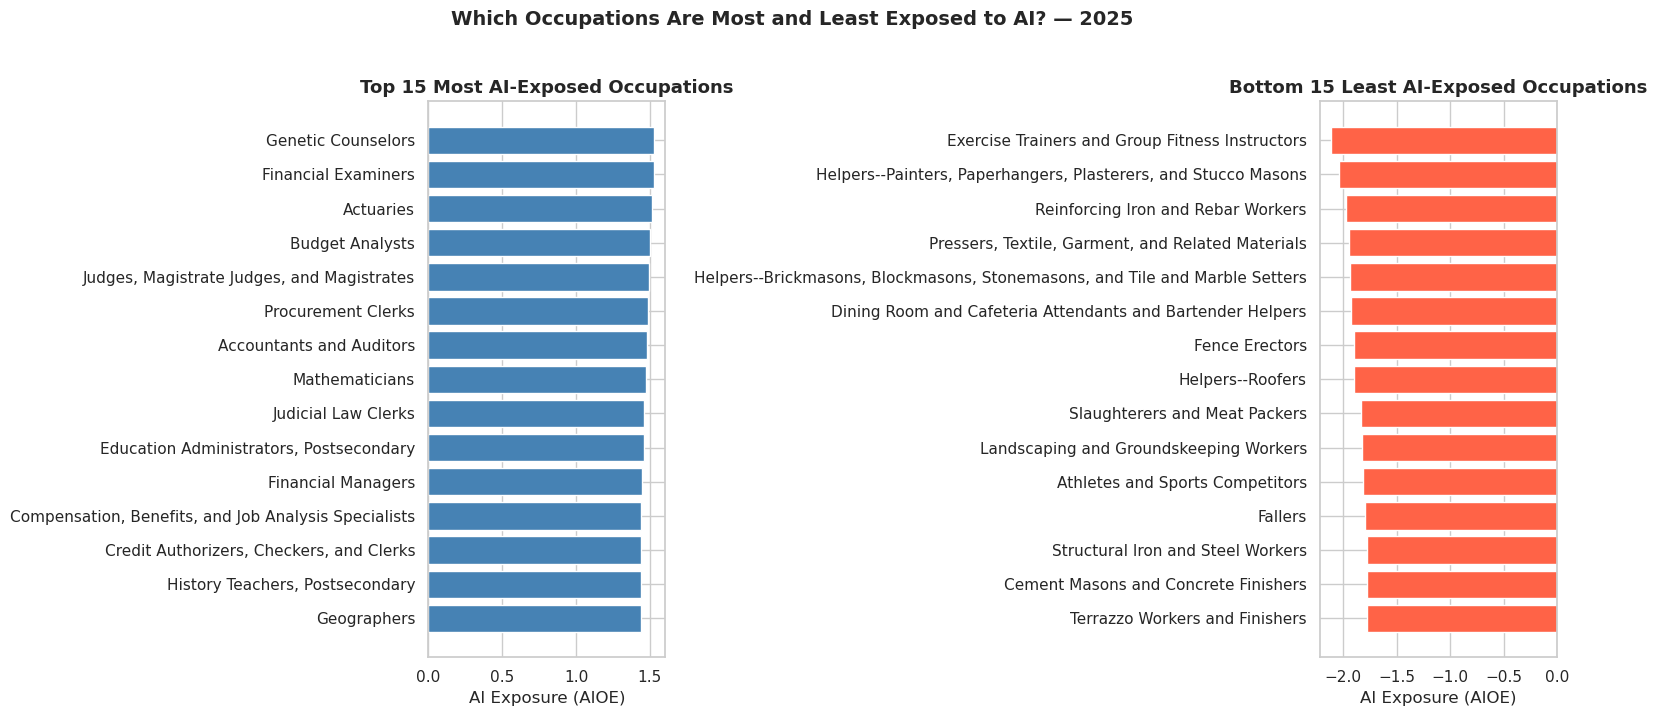

In [9]:
# Top 15 and Bottom 15 occupations by AI exposure
top15 = df.nlargest(15, "AIOE")[["occupation", "AIOE", "annual_wage"]]
bot15 = df.nsmallest(15, "AIOE")[["occupation", "AIOE", "annual_wage"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 15
axes[0].barh(top15["occupation"], top15["AIOE"], color="steelblue")
axes[0].set_title("Top 15 Most AI-Exposed Occupations", 
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("AI Exposure (AIOE)")
axes[0].invert_yaxis()

# Bottom 15
axes[1].barh(bot15["occupation"], bot15["AIOE"], color="tomato")
axes[1].set_title("Bottom 15 Least AI-Exposed Occupations", 
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel("AI Exposure (AIOE)")
axes[1].invert_yaxis()

plt.suptitle("Which Occupations Are Most and Least Exposed to AI? — 2025",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/ai_top_bottom_occupations.png", 
            dpi=150, bbox_inches="tight")
plt.show()